In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [12]:
from tensorflow.keras import datasets

In [13]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

In [14]:
x_train,x_test=x_train/255.0,x_test/255.0

In [15]:
model=Sequential([
                        Flatten(input_shape=(28,28)),
                        Dense(64,activation='relu'),
                        Dense(10,activation='softmax')
                       ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
print("Training model...")
model.fit(x_train,y_train,epochs=2)

Training model...
Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8632 - loss: 0.4909
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9554 - loss: 0.1534


In [18]:
loss,acc=model.evaluate(x_test,y_test,verbose=0)
print(f"\n Test Accuracy: {acc:.2f}")


 Test Accuracy: 0.96


In [19]:
#index=np.random.randint(0,len(x_test))
index = 11
image=x_test[index]
label=y_test[index]

In [20]:
prediction=model.predict(image.reshape(1,28,28))
predicted_digit=np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


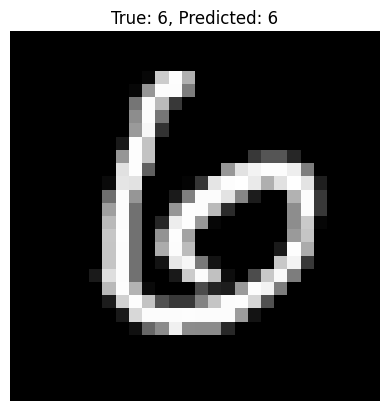

In [21]:
plt.imshow(image,cmap='gray')
plt.title(f"True: {label}, Predicted: {predicted_digit}")
plt.axis("off")
plt.show()

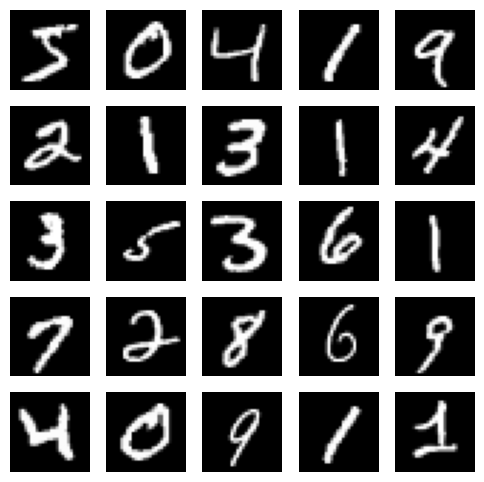

In [22]:
fig, ax = plt.subplots(5, 5, figsize=(6, 6))
k = 0
for i in range(5):
    for j in range(5):
      ax[i][j].imshow(x_train[k], cmap='gray')
      ax[i][j].axis('off')
      k += 1
plt.show()

In [23]:
print("Sample pixel:", x_train[0][5])
print("Sample test row:", x_test[50])

Sample pixel: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.01176471 0.07058824 0.07058824 0.07058824 0.49411765 0.53333333
 0.68627451 0.10196078 0.65098039 1.         0.96862745 0.49803922
 0.         0.         0.         0.        ]
Sample test row: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.

In [24]:
train_df = pd.read_csv('/content/sample_data/mnist_train_small.csv')
test_df = pd.read_csv('/content/sample_data/mnist_test.csv')

In [25]:
print(train_df.head())

   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]


In [26]:
print(train_df.tail())

       6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
19994  0  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19995  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19996  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19997  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19998  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   

       0.584  0.585  0.586  0.587  0.588  0.589  0.590  
19994      0      0      0      0      0      0      0  
19995      0      0      0      0      0      0      0  
19996      0      0      0      0      0      0      0  
19997      0      0      0      0      0      0      0  
19998      0      0      0      0      0      0      0  

[5 rows x 785 columns]


In [27]:
n_classes = 10
print("Shape before one-hot:", y_train.shape)

y_train = to_categorical(y_train, n_classes)
y_test = to_categorical(y_test, n_classes)

print("Shape after one-hot:", y_train.shape)


Shape before one-hot: (60000,)
Shape after one-hot: (60000, 10)


In [28]:
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8595 - loss: 0.4985 - val_accuracy: 0.9614 - val_loss: 0.1291
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9662 - loss: 0.1094 - val_accuracy: 0.9722 - val_loss: 0.0884
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9794 - loss: 0.0680 - val_accuracy: 0.9740 - val_loss: 0.0810
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9837 - loss: 0.0488 - val_accuracy: 0.9768 - val_loss: 0.0765
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9904 - loss: 0.0331 - val_accuracy: 0.9777 - val_loss: 0.0718
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9920 - loss: 0.0261 - val_accuracy: 0.9785 - val_loss: 0.0688
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9941 - loss: 0.0194 - val_accuracy: 0.9777 - val_loss: 0.0728
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9937 - loss: 0.0186 - val_accura

In [30]:
print(history.history.keys())
print("Training Accuracy:", history.history['accuracy'])
print("Training Loss:", history.history['loss'])
print("Validation Accuracy:", history.history['val_accuracy'])
print("Validation Loss:", history.history['val_loss'])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Training Accuracy: [0.9228666424751282, 0.9686166644096375, 0.9793166518211365, 0.984250009059906, 0.9882833361625671, 0.9916333556175232, 0.9931333065032959, 0.9933666586875916, 0.9951333403587341, 0.9960833191871643]
Training Loss: [0.27015960216522217, 0.10337292402982712, 0.06777373701334, 0.04971238970756531, 0.03771958872675896, 0.02649773471057415, 0.02153918705880642, 0.020192088559269905, 0.014663239941000938, 0.011598065495491028]
Validation Accuracy: [0.9613999724388123, 0.9721999764442444, 0.9739999771118164, 0.9768000245094299, 0.9776999950408936, 0.9785000085830688, 0.9776999950408936, 0.9800000190734863, 0.9797000288963318, 0.9771999716758728]
Validation Loss: [0.1290566325187683, 0.08840631693601608, 0.08100496232509613, 0.07648953050374985, 0.07176397740840912, 0.06884821504354477, 0.07282394915819168, 0.07517186552286148, 0.07722346484661102, 0.08714477717876434]


In [31]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Loss:", loss, "Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9731 - loss: 0.0966
Loss: 0.08714473247528076 Accuracy: 0.9771999716758728


In [32]:

predictions = model.predict(x_test)
print("First prediction probabilities:", predictions[0])
print("Predictions shape:", predictions.shape)

y_pred = tf.math.argmax(predictions, axis=1)
print("Predicted output (first):", y_pred[0])

print("Actual output (first):", tf.math.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
First prediction probabilities: [8.3188491e-11 1.3681347e-09 7.3605150e-10 8.7126068e-08 2.0798338e-14
 5.3869165e-10 2.2654794e-15 9.9999923e-01 4.3202091e-11 5.9372763e-07]
Predictions shape: (10000, 10)
Predicted output (first): tf.Tensor(7, shape=(), dtype=int64)
Actual output (first): tf.Tensor(7, shape=(), dtype=int64)
